In [40]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [41]:
### SET UP FOR A THREE LEVEL SYSTEM
ground = Qobj([[1],[0],[0]])  
storage = Qobj([[0],[1],[0]]) 
excited = Qobj([[0],[0],[1]]) 

sigma_ee = Qobj([[0,0,0],[0,0,0],[0,0,1]])  # |e><e| (excited state population)

sigma_ge = Qobj([[0,0,0],[0,0,0],[1,0,0]])  # |e><g| (transition from g to e)
sigma_eg = Qobj([[0,0,1],[0,0,0],[0,0,0]])  # |g><e| (transition from e to g)

sigma_se = Qobj([[0,0,0],[0,0,0],[0,1,0]])  # |e><s| (transition from s to e)
sigma_es = Qobj([[0,0,0],[0,0,1],[0,0,0]])  # |s><e| (transition from e to s)

sigma_gs = Qobj([[0,0,0],[1,0,0],[0,0,0]])  # |s><g| (transition from g to s)
sigma_sg = Qobj([[0,1,0],[0,0,0],[0,0,0]])  # |g><s| (transition from s to g)

## Hamiltonian
The Hamiltonian for the three-level system is

$$ \hat{H} = g_{ge} (\hat{\textbf{a}}_{ge}(t)\hat{\sigma}_{ge}+ \hat{\textbf{a}}_{ge}^\dagger(t)\hat{\sigma}_{eg}) +
g_{se} (\hat{\textbf{a}}_{se}(t)\hat{\sigma}_{se} + \hat{\textbf{a}}_{se}^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee}
$$

The $\hat{\textbf{a}}_{ge}(t)$ corresponds to the input pulse (signal), whereas $\hat{\textbf{a}}_{se}(t)$ corresponds to the control pulse we apply. Again, we seem to ultimately ignore the vacuum field after expectation valuing.  The couplings $g_{se}, g_{ge}$ should be determined by the medium (constants). We will denote $\beta(t)$ and $\alpha(t)$ as the expectation value of $\hat{\textbf{a}}_{se}(t)$ and  $\hat{\textbf{a}}_{ge}(t)$ respectively. After expectation valuing everything:

$$ \hat{H} = g_{ge} (\alpha(t)\hat{\sigma}_{ge}+ \alpha^\dagger(t)\hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee} $$

Assuming the input signal is real,

$$ \hat{H} = g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee}$$

## Decay Terms

The decay terms are now given by:
$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{C}{g_{ge}^*}\hat{\sigma}_{eg}, -{g_{se}^*}\hat{\sigma}_{es}\end{bmatrix} $$

The first term of this operator is from the same bath that $\alpha$ comes from, the second comes from a completely separate bath (i.e. diffuse, free space).Would need a different factor for the se decay term but for now, make $g_{se}$ small, $\sim 1/C * g_{eg}$ (typically cooperativity is not defined for the beta pulse). For the sake of simplicity, we will remove the es term as we don't want this type of decay ideally.

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{C}{g_{ge}^*}\hat{\sigma}_{eg} \end{bmatrix} $$

Note that the Lindblad term does not include a signal or coupling term: the signal does not affect the dynamics of the Hamiltonian. when you adiabatically eliminate the excited state, the effective Rabi frequency between gs state appears (why?). In our current simulation, there is no adiabatic elimination, so we do not include the signal in the Lindblad terms. After the adiabatic elimination, signal shows up in the Lindblad terms. This is different from the two-level system: our vacuum Rabi frequency is defined by $g$ but here, we have a constant vacuum Rabi frequency defined by $g_{se}$, for example. 

### Note of Caution
In our formalism, we "included" $C$ in the $g_{eg}$ term such that it is dependent on cooperativity. In a cavity, the cooperativity of the $g_{ge}$ is enhanced by $C$. We could alternatively (as shown below) include cooperativity $C$ on the Hamiltonian and first decay term, rather than the $\frac{1}{C}$ on the second term of the decay.

$$ \hat{H} = C \cdot g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee} $$

$$  \mathbf{L} = \begin{bmatrix} -C{g_{ge}^*}\hat{\sigma}_{eg}, -{g_{ge}^*}\hat{\sigma}_{eg} \end{bmatrix} $$

Based on the freespace derivation, the Lindblad term has a factor of (C+1)/C. 

- $g_{ge} = \sqrt{2\gamma C}$


### Tests:

$$ \hat{H} = g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee} $$

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{C}{g_{ge}^*}\hat{\sigma}_{eg} \end{bmatrix} $$

1. Set $\beta(t) = 0$.  Without dissipation, we expect the signal to simply spin up the atom slightly to the excited state. Storage state should be 0. With dissipation (only eg dissipation), it should behave as the typical TLS and decay. These two cases work.

2. Set $\beta(t) = C$ (contant).

3. Set $\beta(t)$ equal to the optimal case. Without dissipation, I'm not sure what to expect because this $\beta(t)$ is tailored to the case where there is dissipation. With dissipation (eg dissipation only), I'd expect the excited state probability to reach 0.01, same as the number of photons. 

Let's continue with this for now as before and just simulate.

Area of alpha: 0.00999999999999231


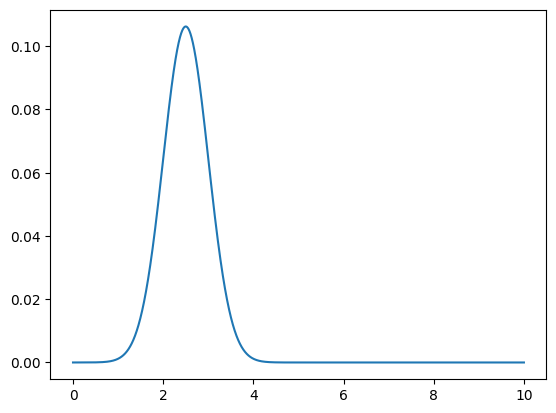

In [42]:
T = 10 # total time (input pulse "duration")
N = 5000 # number of time steps

g_se = 1
g_ge = 1/np.sqrt(C*gamma*2) # *C # Set this to 0 to simulate TLS with constant coupling

mu, sigma = 2.5, 0.5 # 2.5, 0.5 # defined for a Gaussian input pulse

# Returned area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    amp = 0.1 # small amplitude
    return amp*(gaussian(mu, sigma, t)) 

# Same example as Gorshkov 34
'''def alpha_in(t):
    A = 2.09
    return A*(np.exp(-30*(t/(T/2)-0.5)**2)-np.exp(-7.5)) / np.sqrt(T/2)
'''
time = np.linspace(0, T, N)
alpha = alpha_in(time) # input signal

plt.plot(time, alpha)
print("Area of alpha:", integrate.simps(alpha**2, time))

### Optimal coupling $\beta(t)$

From Gorshkov's paper, the optimal control pulse shape to store the incoming signal $\alpha_{in}$: 

$$\beta(t)= -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}} \cdot \frac{\alpha_{in}(t)}{\sqrt{\int_0^t{|\alpha_{in}(t)|^2 dt}}} \cdot
\text{exp} \left(\frac{i \Delta \cdot h(t, T)}{\gamma^2(1+C)^2+\Delta^2} \right)$$


- $h(t, T) = \int_t^T |g_{se}\beta(t)|^2 dt$.  What is $T$? Seems to be pulse duration, which here we will simply treat as the end of time array. (integrated phase accumulation due to AC stark shift. Note that this would become 0 if we rotated into an AC stark shifted frame). There will be discrete time steps in the Hamiltonian due to h(t) integrator. If we can make this more discontinuous at second order rather than first order, the simulation may scale better with time.
- $C$ is cavity cooperativity.
- $\gamma$ is decay rate (of the excited state?)
- $\Delta$ is the detuning of the Raman memory
- $T$ is the duration of the input pulse

We can rewrite this for the code as:

$$ \beta(t) = a \times b \times \text{exp} \left(\frac{i\Delta h(t, T)}{c}\right)$$
- $a = -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}}$
- $b = \frac{\alpha_{in}(t)}{\sqrt{\int_0^t{|\alpha_{in}(t)|^2dt}}}$
- $c = \gamma^2(1+C)^2+\Delta^2$

Note: could be interesting trying to simulate the Gorshkov Hamiltonian with its 50 terms. Also, when we are computing h, note that $|\beta(t)|^2$ will be $|a \cdot b|^2$. The derivative of $h$ corresponds to the frequency and therefore energy shift.

In [43]:
gamma = 1       # decay rate
C = 200           # cooperativity (higher = more efficient)
Delta = 100        # detuning

# Precompute prefactors (constants)
#a = -(gamma*(1+C) - 1j*Delta) / np.sqrt(2*gamma*(1+C))
#c = gamma**2*(1+C)**2 + Delta**2

a = -(gamma*(1/C+1) - 1j*Delta) / np.sqrt(2*gamma*(1/C+1))
c = gamma**2*(1/C+1)**2 + Delta**2

# Compute b
b = [0]
for i in range(1, len(time)):
    integral_val = integrate.simps(abs(alpha[0:i])**2, time[0:i]) # integral (0 to t) of |alpha|^2
    if (integral_val == 0):
        b.append(0)
    else:      
        b.append(alpha[i] / (np.sqrt(integral_val)))
b = np.array(b)

In [44]:
# Returns the integral of |beta(t)|^2 from t[idx] to t[-1]
def get_h(beta_vals, idx, time):
    h_val = integrate.simps(np.abs(beta_vals[idx:-1])**2, time[idx:-1]) # Integrate beta from time[idx] to time[-1]
    return h_val

100%|██████████| 4999/4999 [00:01<00:00, 3039.07it/s]


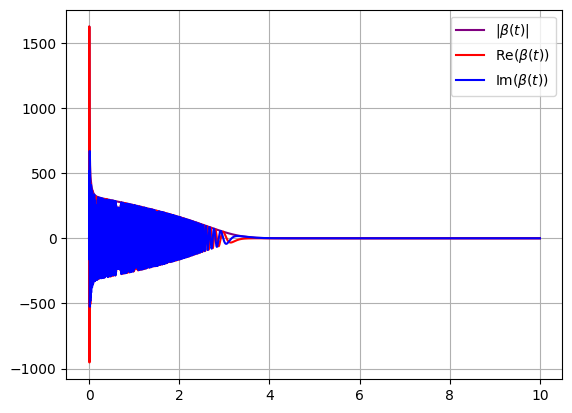

In [45]:
beta_vals = np.array([0])
h_vals = np.array([0])

for idx in tqdm(range(0, len(time)-1)):
    h = get_h(a*b, idx, time)
    if np.imag(h) != 0: print('Imaginary part detected')
    beta_vals = np.append(beta_vals, a*b[idx]*np.exp(1j*Delta*h/c))
    h_vals = np.append(h_vals, h)

def beta(t):
    #return 0
    if t == time[0]: return 0
    else:            return np.interp(t, time, beta_vals)  # Interpolate smoothed g values    
    
# Plot results
plt.plot(time, abs(beta_vals), color='purple', label=r'$|\beta(t)|$')
plt.plot(time, np.real(beta_vals), color='red', label=r'Re$(\beta(t))$')
plt.plot(time, np.imag(beta_vals), color='blue', label=r'Im$(\beta(t))$')
plt.grid()
plt.legend()

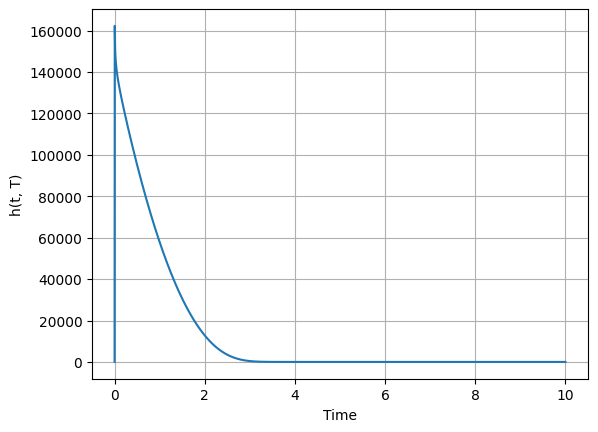

In [46]:
plt.plot(time, h_vals)
plt.xlabel('Time'); plt.ylabel('h(t, T)')
plt.grid()

Limit in the Gorshkov paper: 
- $|\Delta| \gg \gamma C$ (Raman configuration)
- Adiabatic elimination condition: $TC\gamma \gg 1$ ($T$ is the duration of the incoming pulse)
- Maximum efficiency: $\frac{C}{1+C}$
- $|\Omega| \sim |\Delta|/ \sqrt{\gamma C T}$

$\gamma$ is defined as the decay rate into unwanted modes of optical polarization. $\gamma \gt \gamma_e/2$ where $\gamma_e$ is the spontaneous decay from the excited state.

In [47]:
print(Delta, gamma*C) # Delta should be much greater than gamma*C (gamma*C is decay rate for P into desired mode)
print(sigma*C*gamma) # Verify this is greater than 1
print(abs(beta_vals), Delta/np.sqrt(gamma*C*sigma)) # Should be on the same order
print(abs(np.max(beta_vals)))
print(C/(1+C)) # max efficiency

100 200
100.0
[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.24359676e-47
 1.17120813e-47 1.10301552e-47] 10.0
1624.954995883916
0.9950248756218906


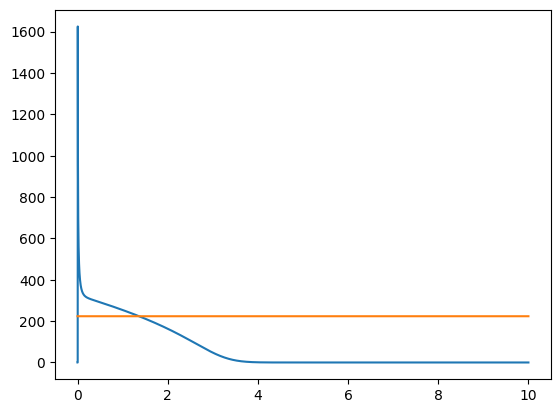

In [48]:
plt.plot(time, np.abs(beta_vals))
plt.plot(time, np.ones(len(time))*np.abs(gamma*C + 1j*Delta))

## Accounting for AC Stark Shift
The pump $\beta(t)$ shifts the energy state ("dressed"), which causes a detuning on the eg transition. This makes $\alpha$ out of resonance with the eg transition. Thus, $\alpha$ may need a detuning term like $e^{i \Delta t}$ or Hamiltonian has additional delta dependence (shift excited state, sigma ee term). We do the latter as based on Gorshkov, we shold not need to adjust $\alpha_{in}$ as our Hamiltonian includes a detuning term and $\beta$ adjusts for it (see Gorshkov).

Confused about how this doesn't apply to the TLS. 

How does AC Stark shift get accounted for in qutip simulations?

In contrast to the three-level system, efficiencies don't work as well because of the AC stark shift, which accumulates phase and shifts the energy between the two ground states.

In [49]:
### ---------------------------- HAMILTONIAN ---------------------------------
H_signal = sigma_ge + sigma_eg
H_coupling = sigma_se
H_coupling_dag = sigma_es
H_detuning = sigma_ee 

def H_detuning_coeff(t, args):
    return Delta

def H_signal_coeff(t, args): 
    return g_ge * alpha_in(t) 

def H_coupling_coeff(t, args):
    return g_se * beta(t)

def H_coupling_dag_coeff(t, args):
    return g_se * np.conjugate(beta(t))

H = [[H_detuning, H_detuning_coeff], [H_signal, H_signal_coeff], [H_coupling, H_coupling_coeff], [H_coupling_dag, H_coupling_dag_coeff]] # Final Hamiltonian 

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -{g_{se}^*} \hat{\sigma}_{es} \end{bmatrix} $$


In [50]:
# ------------------DISSIPATION OPERATORES (collapse operators)-----------------
def col_coeff_es(t, args): 
    return -np.conjugate(g_se) 

def col_coeff_eg(t, args): 
    return -np.conjugate(g_ge) 

c_op_list = [] # No dissipation
c_op_list = [[sigma_eg, col_coeff_eg], [sigma_eg, -1/C]]  # only eg dissipation
#c_op_list = [[sigma_es, col_coeff_es], [sigma_eg, col_coeff_eg], [sigma_eg, -1/C]]  # eg and es dissipation

### SIMULATE: starting from the ground state, solve Schrodinger equation
psi0 = ground # |g> 
result = mesolve(H, psi0, time, c_op_list) 

In [51]:
###--------------------- RESULTS ---------------------------
prob_g = [] # probability of finding state in |g>
prob_s = [] # probability of finding state in |s>
prob_e = [] # probability of finding state in |e>

S = [] # expectation value of |g><s|

for i in range(0, len(result.states)):
    # No dissipation (result outputs states) 
    p_g, p_s, p_e = abs(result.states[i][0])**2, abs(result.states[i][1])**2, abs(result.states[i][2])**2
    
    # With dissipation (result outputs density operators)
    p_g, p_s, p_e = result.states[i][0][0], result.states[i][1][1], result.states[i][2][2]
    
    prob_g = np.append(prob_g, p_g)
    prob_s = np.append(prob_s, p_s)
    prob_e = np.append(prob_e, p_e)

    S = np.append(S, expect(sigma_gs, result.states[i]))

S_ideal = []

Final |s> probability:  1.1741484123482449e-05


C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


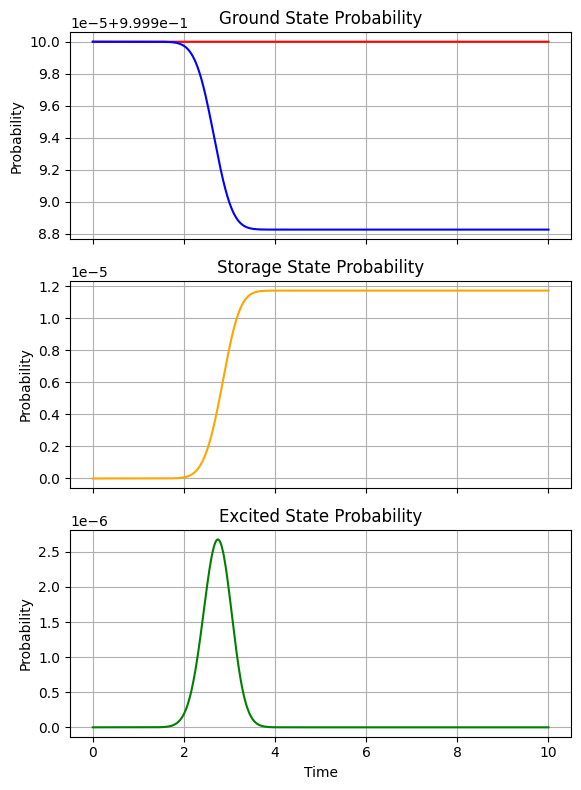

In [52]:
print('Final |s> probability: ', abs(prob_s[-1]))
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# Sanity checks
axs[0].plot(time, prob_g+prob_e+prob_s, color='red')
axs[0].plot(time, prob_g, color='blue')
axs[0].set_ylabel('Probability')
axs[0].set_title('Ground State Probability')
axs[0].grid()

axs[1].plot(time, prob_s, color='orange')
axs[1].set_ylabel('Probability')
axs[1].set_title('Storage State Probability')
axs[1].grid()

axs[2].plot(time, prob_e, color='green')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Probability')
axs[2].set_title('Excited State Probability')
axs[2].grid()
plt.tight_layout()